# Klasifikasi Sentimen, Toxicity, dan Emosi pada Teks Forum
### Menggunakan Model Machine Learning Berbasis Bahasa Indonesia

---
**Anggota Kelompok:**
* **Matthew Yuslih**
* Sebastian Obert
* Jansen Caesar
* Pierre Rambe
* Manuel Manatap

---
**Deskripsi Singkat:**
Pada training model ini, kami melakukan perbandingan terlebih dahulu pada dua alogritma
* SVM
* Naive Bayes
Lalu setelah mendapatkan model terbaik, kami melakukan hyperparameter tuning untuk meningkatkan peforma model

# 1. Load DataSet

### Setup (Import Library & Fungsi auto load CSV)
---

In [5]:
import pandas as pd
import chardet
import os
from IPython.display import display, Markdown

def load_csv_auto(filename):
    if not os.path.exists(filename):
        print(f"Error: File '{filename}' TIDAK DITEMUKAN.")
        return None
        
    encodings_to_try = ['utf-8', 'latin1', 'iso-8859-1', 'cp1252']
    
    for enc in encodings_to_try:
        try:
            df = pd.read_csv(filename, encoding=enc)
            return df
        except UnicodeDecodeError:
            continue 
        except Exception as e:
            print(f" Error lain saat load '{filename}' ({enc}): {e}")
            return None

    print(f" Percobaan standar gagal untuk '{filename}', mencoba deteksi mendalam...")
    try:
        with open(filename, "rb") as f:
            result = chardet.detect(f.read(100000)) 
        detected_enc = result['encoding']
        return pd.read_csv(filename, encoding=detected_enc)
    except Exception as e:
        print(f" Gagal total memuat '{filename}'. Error: {e}")
        return None

def preview_dataset(df, nama):
    if df is not None:
        display(df.head())
        print(f"Dataset Info:")
        print(f"- Jumlah Baris: {df.shape[0]}")
        print(f"- Jumlah Kolom: {df.shape[1]}")
    else:
        print(f" Data {nama} GAGAL DILOAD.")

### Load Dataset Emotion
---

In [6]:
df_emotion = load_csv_auto("Dataset_Emotion.csv")
preview_dataset(df_emotion, "Emotion")

,label,tweet
0,anger,"Soal jln Jatibaru,polisi tdk bs GERTAK gubernu..."
1,anger,"Sesama cewe lho (kayaknya), harusnya bisa lebi..."
2,happy,Kepingin gudeg mbarek Bu hj. Amad Foto dari go...
3,anger,"Jln Jatibaru,bagian dari wilayah Tn Abang.Peng..."
4,happy,"Sharing pengalaman aja, kemarin jam 18.00 bata..."


Dataset Info:
- Jumlah Baris: 4401
- Jumlah Kolom: 2


### Load Dataset Sentiment
---

In [7]:
df_sentiment = load_csv_auto("Dataset_Sentiment.csv") 
preview_dataset(df_sentiment, "Sentiment")

,kalimat,sentiment
0,Kalimat-kalimat tersebut adalah sebagai berikut,0
1,Manusia membutuhkan makanan dan air supaya men...,1
2,Tanaman hijau menggunakan air untuk membuat ma...,0
3,Tanaman yang tidak mendapat air akan layu dan ...,1
4,Keberhasilan belajar murid tidak hanya bergant...,1


Dataset Info:
- Jumlah Baris: 12609
- Jumlah Kolom: 2


### Load Dataset Toxicity
---

In [8]:
df_toxicity = load_csv_auto("Dataset_Toxicity.csv")
preview_dataset(df_toxicity, "Toxicity")

,Tweet,HS,Abusive,HS_Individual,HS_Group,HS_Religion,HS_Race,HS_Physical,HS_Gender,HS_Other,HS_Weak,HS_Moderate,HS_Strong
0,- disaat semua cowok berusaha melacak perhatia...,1,1,1,0,0,0,0,0,1,1,0,0
1,RT USER: USER siapa yang telat ngasih tau elu?...,0,1,0,0,0,0,0,0,0,0,0,0
2,"41. Kadang aku berfikir, kenapa aku tetap perc...",0,0,0,0,0,0,0,0,0,0,0,0
3,USER USER AKU ITU AKU\n\nKU TAU MATAMU SIPIT T...,0,0,0,0,0,0,0,0,0,0,0,0
4,USER USER Kaum cebong kapir udah keliatan dong...,1,1,0,1,1,0,0,0,0,0,1,0


Dataset Info:
- Jumlah Baris: 13169
- Jumlah Kolom: 13


# 2. EDA (Exploratory Data Analysis)

### Import
---

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns

### Melakukan pengecekan Nan Values dan duplicate column pada masing masing dataset
---

In [10]:
def cek_kesehatan_data(df, nama_dataset):
    print(f"--- DIAGNOSA DATASET: {nama_dataset} ---")

    print(f"Ukuran Data: {df.shape[0]} baris, {df.shape[1]} kolom")

    null_count = df.isnull().sum().sum()
    if null_count > 0:
        print(f"PERINGATAN: Ada {null_count} missing values (NaN)!")
        print(df.isnull().sum()) 
    else:
        print("Aman: Tidak ada missing values.")

    duplikat = df.duplicated().sum()
    if duplikat > 0:
        print(f"PERINGATAN: Ada {duplikat} data duplikat!")
    else:
        print("Dataset tersebut tidak terdeteksi adanya duplikat.")

    print(f"Kolom tersedia: {list(df.columns)}")
    print("-" * 40 + "\n")

cek_kesehatan_data(df_emotion, "Emotion")
cek_kesehatan_data(df_sentiment, "Sentiment")
cek_kesehatan_data(df_toxicity, "Toxicity")

--- DIAGNOSA DATASET: Emotion ---
Ukuran Data: 4401 baris, 2 kolom
Aman: Tidak ada missing values.
PERINGATAN: Ada 11 data duplikat!
Kolom tersedia: ['label', 'tweet']
----------------------------------------

--- DIAGNOSA DATASET: Sentiment ---
Ukuran Data: 12609 baris, 2 kolom
Aman: Tidak ada missing values.
PERINGATAN: Ada 1516 data duplikat!
Kolom tersedia: ['kalimat', 'sentiment']
----------------------------------------

--- DIAGNOSA DATASET: Toxicity ---
Ukuran Data: 13169 baris, 13 kolom
Aman: Tidak ada missing values.
PERINGATAN: Ada 125 data duplikat!
Kolom tersedia: ['Tweet', 'HS', 'Abusive', 'HS_Individual', 'HS_Group', 'HS_Religion', 'HS_Race', 'HS_Physical', 'HS_Gender', 'HS_Other', 'HS_Weak', 'HS_Moderate', 'HS_Strong']
----------------------------------------



### Menghapus semua duplikat dan Nan Values
---

In [11]:
# 1. Dataset Emotion
df_emotion.drop_duplicates(subset=['tweet'], inplace=True)
df_emotion.rename(columns={'tweet': 'text', 'label': 'label'}, inplace=True)
print(f"Emotion: Duplikat dibuang. Sisa {df_emotion.shape[0]} data.")

# 2. Dataset Sentiment
df_sentiment.drop_duplicates(subset=['kalimat'], inplace=True)
df_sentiment.rename(columns={'kalimat': 'text', 'sentiment': 'label'}, inplace=True)
print(f"Sentiment: Duplikat dibuang. Sisa {df_sentiment.shape[0]} data.")

# 3. Dataset Toxicity
df_toxicity.drop_duplicates(subset=['Tweet'], inplace=True)
df_toxicity.rename(columns={'Tweet': 'text'}, inplace=True)
print(f"Toxicity: Duplikat dibuang. Sisa {df_toxicity.shape[0]} data.")

Emotion: Duplikat dibuang. Sisa 4389 data.
Sentiment: Duplikat dibuang. Sisa 11093 data.
Toxicity: Duplikat dibuang. Sisa 13023 data.


### Visualisasi (EDA Chart)
---


--- MENAMPILKAN GRAFIK BERSIH ---


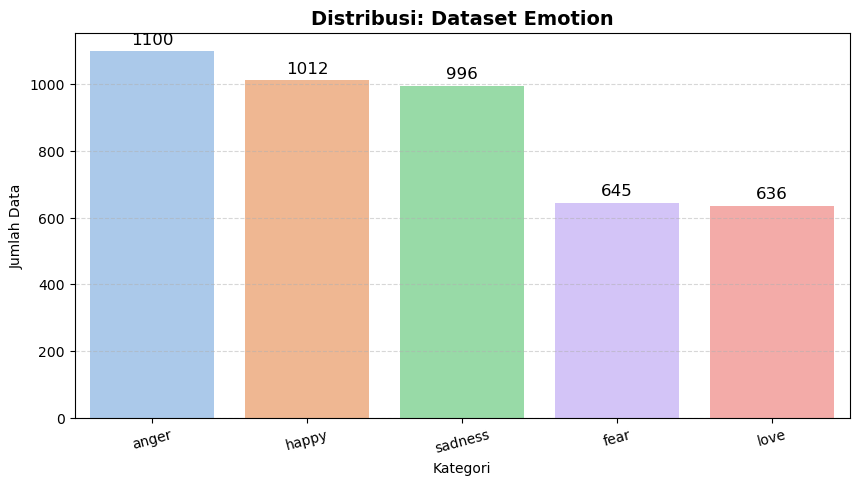

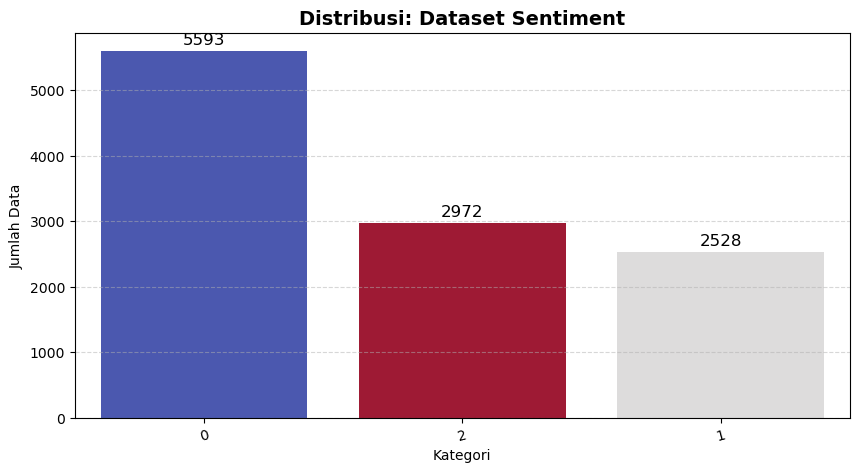

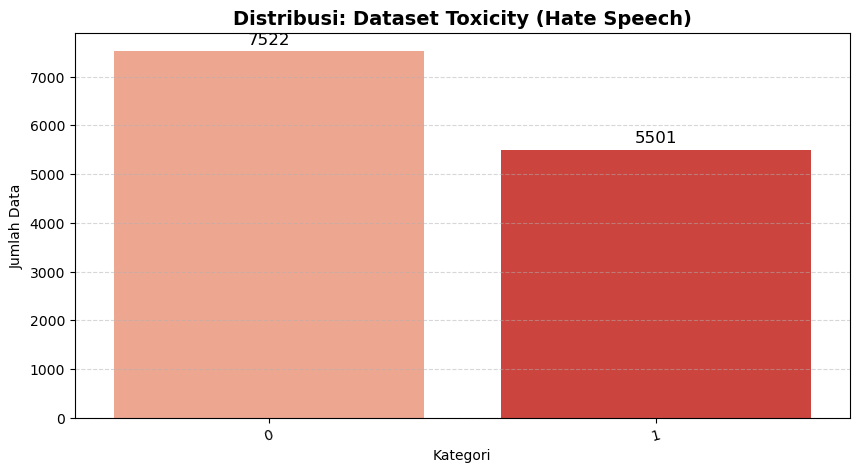

In [12]:
def plot_sebaran(df, kolom_target, judul, warna='viridis'):
    plt.figure(figsize=(10, 5))

    ax = sns.countplot(
        x=kolom_target, 
        data=df, 
        hue=kolom_target,     
        legend=False,        
        palette=warna, 
        order=df[kolom_target].value_counts().index
    )

    for p in ax.patches:
        height = p.get_height()
        if height > 0: 
            ax.annotate(f'{int(height)}', 
                        (p.get_x() + p.get_width() / 2., height), 
                        ha='center', va='baseline', fontsize=12, color='black', xytext=(0, 5), 
                        textcoords='offset points')
    
    plt.title(f'Distribusi: {judul}', fontsize=14, fontweight='bold')
    plt.xlabel('Kategori')
    plt.ylabel('Jumlah Data')
    plt.xticks(rotation=15)
    plt.grid(axis='y', linestyle='--', alpha=0.5)
    plt.show()

print("\n--- MENAMPILKAN GRAFIK BERSIH ---")

# 1. Emotion
plot_sebaran(df_emotion, 'label', 'Dataset Emotion', 'pastel')
# 2. Sentiment
plot_sebaran(df_sentiment, 'label', 'Dataset Sentiment', 'coolwarm')
# 3. Toxicity 
plot_sebaran(df_toxicity, 'HS', 'Dataset Toxicity (Hate Speech)', 'Reds')

### Analisis Distribusi Label Toxicity dan Penggabungan Label Toxicity
---

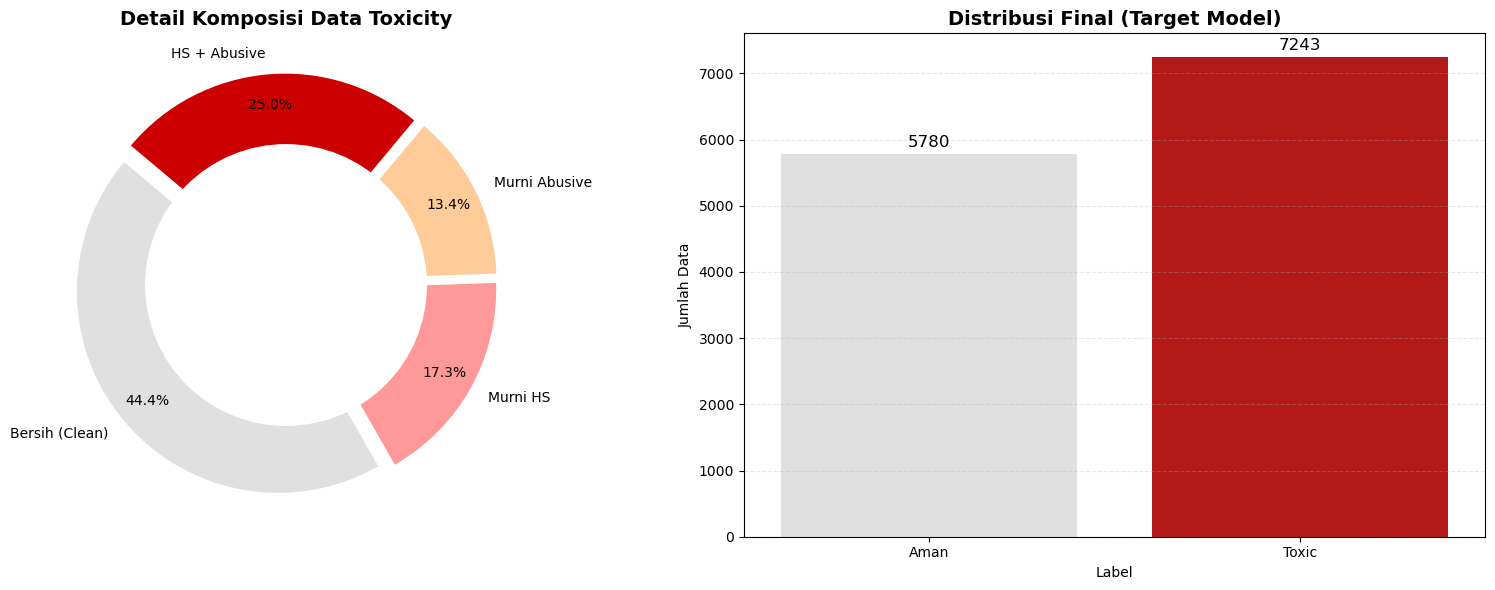

In [13]:
hs_only = df_toxicity[(df_toxicity['HS'] == 1) & (df_toxicity['Abusive'] == 0)].shape[0]
abusive_only = df_toxicity[(df_toxicity['HS'] == 0) & (df_toxicity['Abusive'] == 1)].shape[0]
both = df_toxicity[(df_toxicity['HS'] == 1) & (df_toxicity['Abusive'] == 1)].shape[0]
clean = df_toxicity[(df_toxicity['HS'] == 0) & (df_toxicity['Abusive'] == 0)].shape[0]

df_toxicity['final_label'] = ((df_toxicity['HS'] == 1) | (df_toxicity['Abusive'] == 1)).astype(int)

fig, ax = plt.subplots(1, 2, figsize=(16, 6))

labels = ['Bersih (Clean)', 'Murni HS', 'Murni Abusive', 'HS + Abusive']
sizes = [clean, hs_only, abusive_only, both]
colors = ['#e0e0e0', '#ff9999', '#ffcc99', '#cc0000'] 
explode = (0.05, 0.05, 0.05, 0.05) 

ax[0].pie(sizes, labels=labels, colors=colors, autopct='%1.1f%%', startangle=140, pctdistance=0.85, explode=explode)
centre_circle = plt.Circle((0,0),0.70,fc='white')
ax[0].add_artist(centre_circle)
ax[0].set_title('Detail Komposisi Data Toxicity', fontsize=14, fontweight='bold')

sns.countplot(
    x='final_label', 
    data=df_toxicity, 
    hue='final_label', 
    legend=False, 
    palette=['#e0e0e0', '#cc0000'], 
    ax=ax[1]
)

ax[1].set_title('Distribusi Final (Target Model)', fontsize=14, fontweight='bold')
ax[1].set_xlabel('Label')
ax[1].set_ylabel('Jumlah Data')

ax[1].set_xticks([0, 1]) 
ax[1].set_xticklabels(['Aman', 'Toxic']) 

ax[1].grid(axis='y', linestyle='--', alpha=0.3)

for p in ax[1].patches:
    height = p.get_height()
    if height > 0:
        ax[1].annotate(f'{int(height)}', 
                    (p.get_x() + p.get_width() / 2., height), 
                    ha='center', va='baseline', fontsize=12, xytext=(0, 5), 
                    textcoords='offset points')

plt.tight_layout()
plt.show()

# 3. Preprocressing

### Import
---

In [15]:
!pip install Sastrawi

In [16]:
import re
import string
from Sastrawi.StopWordRemover.StopWordRemoverFactory import StopWordRemoverFactory

from sklearn.model_selection import train_test_split

from sklearn.feature_extraction.text import TfidfVectorizer


### Data Cleaning
---

In [17]:
factory = StopWordRemoverFactory()
stopwords_indonesia = factory.get_stop_words()

tambahan_alay = ['yg', 'dg', 'rt', 'dgn', 'ny', 'd', 'klo', 'kalo', 'amp', 'biar', 'bikin', 'bilang', 
                 'gak', 'ga', 'krn', 'nya', 'nih', 'sih', 'si', 'tau', 'tdk', 'tuh', 'utk', 'ya', 
                 'jd', 'jgn', 'sdh', 'aja', 'n', 't', 'nyg', 'hehe', 'pen', 'u', 'nan', 'loh', 'rt',
                 '&amp', 'yah', 'user', 'url'] 
stopwords_indonesia.extend(tambahan_alay)
stopwords_set = set(stopwords_indonesia)

def bersihkan_teks(text):
    # Case Folding
    text = str(text).lower()
    
    # Ganti Newline (\n) dengan spasi 
    text = text.replace('\\n', ' ').replace('\n', ' ')
    
    # Hapus Mention & URL
    text = re.sub(r'@\w+', ' ', text)
    text = re.sub(r'http\S+|www\S+|https\S+', ' ', text, flags=re.MULTILINE)
    
    # Hapus kata "USER" 
    text = re.sub(r'\buser\b', ' ', text)
    
    # Ganti Tanda Baca dengan Spasi 
    text = re.sub(r'[^\w\s]', ' ', text)
    
    # Hapus Angka
    text = re.sub(r'\d+', ' ', text)
    
    # Stopword Removal
    kata_kata = text.split()
    kata_bersih = [kata for kata in kata_kata if kata not in stopwords_set]
    
    # Gabung lagi
    return " ".join(kata_bersih)

print("Cleaning Function Ready")

Cleaning Function Ready


### Cleaning Dataset
---

In [18]:
df_emotion['text_clean'] = df_emotion['text'].apply(bersihkan_teks)
df_sentiment['text_clean'] = df_sentiment['text'].apply(bersihkan_teks)
df_toxicity['text_clean'] = df_toxicity['text'].apply(bersihkan_teks)

print("Cleaning Dataset Selesai :")
display(df_toxicity[['text', 'text_clean']].head())

Cleaning Dataset Selesai :


,text,text_clean
0,- disaat semua cowok berusaha melacak perhatia...,disaat semua cowok berusaha melacak perhatian ...
1,RT USER: USER siapa yang telat ngasih tau elu?...,siapa telat ngasih elu edan sarap gue bergaul ...
2,"41. Kadang aku berfikir, kenapa aku tetap perc...",kadang aku berfikir aku tetap percaya tuhan pa...
3,USER USER AKU ITU AKU\n\nKU TAU MATAMU SIPIT T...,aku aku ku matamu sipit diliat mana aku
4,USER USER Kaum cebong kapir udah keliatan dong...,kaum cebong kapir udah keliatan dongoknya awal...


### Data Splitting

In [19]:
def bagi_dataset(df, kolom_text, kolom_label, nama_dataset):
    df_bersih = df[df[kolom_text].str.strip() != ''].copy()

    X = df_bersih[kolom_text]
    y = df_bersih[kolom_label]
    
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
    
    print(f"{nama_dataset} Split Berhasil!")
    print(f"   - Training : {len(X_train)} baris")
    print(f"   - Testing  : {len(X_test)} baris")
    return X_train, X_test, y_train, y_test

print("--- Splitting Data ---")

# 1. Split Emotion
X_train_emo, X_test_emo, y_train_emo, y_test_emo = bagi_dataset(df_emotion, 'text_clean', 'label', 'Emotion')

# 2. Split Sentiment
X_train_sen, X_test_sen, y_train_sen, y_test_sen = bagi_dataset(df_sentiment, 'text_clean', 'label', 'Sentiment')

# 3. Split Toxicity 
X_train_tox, X_test_tox, y_train_tox, y_test_tox = bagi_dataset(df_toxicity, 'text_clean', 'final_label', 'Toxicity')

print("\nSemua data siap untuk ekstraksi fitur!")

--- Splitting Data ---
Emotion Split Berhasil!
   - Training : 3511 baris
   - Testing  : 878 baris
Sentiment Split Berhasil!
   - Training : 8861 baris
   - Testing  : 2216 baris
Toxicity Split Berhasil!
   - Training : 10412 baris
   - Testing  : 2604 baris

Semua data siap untuk ekstraksi fitur!


### Feature Extraction
---

In [20]:
def vektorisasi_tfidf(X_train, X_test, nama_dataset):
    vectorizer = TfidfVectorizer(max_features=5000) 
    X_train_tfidf = vectorizer.fit_transform(X_train)
    X_test_tfidf = vectorizer.transform(X_test)
    
    print(f"{nama_dataset} TF-IDF Selesai!")
    print(f"   - Ukuran Matrix Train: {X_train_tfidf.shape}")
    print(f"   - Ukuran Matrix Test : {X_test_tfidf.shape}")

    return X_train_tfidf, X_test_tfidf, vectorizer

print("--- Feature Extraction ---")

# 1. TF-IDF Emotion
X_train_emo_tfidf, X_test_emo_tfidf, vect_emo = vektorisasi_tfidf(X_train_emo, X_test_emo, "Emotion")

# 2. TF-IDF Sentiment
X_train_sen_tfidf, X_test_sen_tfidf, vect_sen = vektorisasi_tfidf(X_train_sen, X_test_sen, "Sentiment")

# 3. TF-IDF Toxicity
X_train_tox_tfidf, X_test_tox_tfidf, vect_tox = vektorisasi_tfidf(X_train_tox, X_test_tox, "Toxicity")

--- Feature Extraction ---
Emotion TF-IDF Selesai!
   - Ukuran Matrix Train: (3511, 5000)
   - Ukuran Matrix Test : (878, 5000)
Sentiment TF-IDF Selesai!
   - Ukuran Matrix Train: (8861, 5000)
   - Ukuran Matrix Test : (2216, 5000)
Toxicity TF-IDF Selesai!
   - Ukuran Matrix Train: (10412, 5000)
   - Ukuran Matrix Test : (2604, 5000)


# 4. Training Model

### Import dan Buat wadah penyimpanan
---

In [21]:
from sklearn.svm import SVC
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score

models_svm = {}
models_nb = {}

skor_akurasi = {
    'Emotion': {}, 
    'Sentiment': {}, 
    'Toxicity': {}
}

print("Setup Training Siap! Lanjut ke training model.")

Setup Training Siap! Lanjut ke training model.


### Training SVM Model (Sebelum Tuning)
---

In [22]:
from tqdm import tqdm
import time

def train_svm(X_train, y_train, X_test, y_test, topic):
    print(f" [SVM] Sedang melatih dataset: {topic}...")

    for _ in tqdm(range(100), desc=f"Training {topic}", ncols=80):
        time.sleep(0.02)

    svm = SVC(kernel='linear', random_state=42)
    svm.fit(X_train, y_train)

    acc = accuracy_score(y_test, svm.predict(X_test))

    models_svm[topic] = svm
    skor_akurasi[topic]['SVM'] = acc
    print(f"Selesai! Akurasi: {acc*100:.2f}%")

train_svm(X_train_emo_tfidf, y_train_emo, X_test_emo_tfidf, y_test_emo, 'Emotion')
train_svm(X_train_sen_tfidf, y_train_sen, X_test_sen_tfidf, y_test_sen, 'Sentiment')
train_svm(X_train_tox_tfidf, y_train_tox, X_test_tox_tfidf, y_test_tox, 'Toxicity')

print("\n Semua Model SVM Berhasil Dilatih!")


 [SVM] Sedang melatih dataset: Emotion...


Training Emotion: 100%|███████████████████████| 100/100 [00:02<00:00, 48.94it/s]


Selesai! Akurasi: 61.73%
 [SVM] Sedang melatih dataset: Sentiment...


Training Sentiment: 100%|█████████████████████| 100/100 [00:02<00:00, 49.01it/s]


Selesai! Akurasi: 69.27%
 [SVM] Sedang melatih dataset: Toxicity...


Training Toxicity: 100%|██████████████████████| 100/100 [00:02<00:00, 48.94it/s]


Selesai! Akurasi: 87.67%

 Semua Model SVM Berhasil Dilatih!


### Training Naive Bayes Model (tidak tuning, karena hanya sebagai komparasi)
---

In [23]:
from tqdm import tqdm
import time

def train_nb(X_train, y_train, X_test, y_test, topic):
    print(f"[NB] Sedang melatih dataset: {topic}...")

    # Simulasi loading bar
    for _ in tqdm(range(100), desc=f"Training {topic}", ncols=80):
        time.sleep(0.01)  # efek visual, tidak mempengaruhi training

    nb = MultinomialNB()
    nb.fit(X_train, y_train)

    acc = accuracy_score(y_test, nb.predict(X_test))

    models_nb[topic] = nb
    skor_akurasi[topic]['NB'] = acc
    
    print(f"Selesai! Akurasi: {acc*100:.2f}%\n")


# Pemanggilan fungsi
train_nb(X_train_emo_tfidf, y_train_emo, X_test_emo_tfidf, y_test_emo, 'Emotion')
train_nb(X_train_sen_tfidf, y_train_sen, X_test_sen_tfidf, y_test_sen, 'Sentiment')
train_nb(X_train_tox_tfidf, y_train_tox, X_test_tox_tfidf, y_test_tox, 'Toxicity')

print("\nSemua Model Naive Bayes Berhasil Dilatih!")


[NB] Sedang melatih dataset: Emotion...


Training Emotion: 100%|███████████████████████| 100/100 [00:01<00:00, 97.04it/s]


Selesai! Akurasi: 58.88%

[NB] Sedang melatih dataset: Sentiment...


Training Sentiment: 100%|█████████████████████| 100/100 [00:01<00:00, 96.80it/s]


Selesai! Akurasi: 63.22%

[NB] Sedang melatih dataset: Toxicity...


Training Toxicity: 100%|██████████████████████| 100/100 [00:01<00:00, 97.17it/s]

Selesai! Akurasi: 85.18%


Semua Model Naive Bayes Berhasil Dilatih!


### Training SVM dengan Hyperparameter Tuning
---

In [24]:
from sklearn.model_selection import GridSearchCV
from tqdm import tqdm
import time

print("Hyperparameter Tuning...\n")

all_grids = {}

def cari_settingan_terbaik(X_train, y_train, topic):
    print(f"\n{'='*40}")
    print(f"Sedang mengulik dataset: {topic}...\n")

    # Loading bar simulasi sebelum GridSearch
    for _ in tqdm(range(80), desc=f"Menelusuri Param {topic}", ncols=80):
        time.sleep(0.01)

    param_grid = {
        'C': [1, 10],
        'kernel': ['linear', 'rbf'],
        'gamma': ['scale']
    }
    
    print("\nMelakukan GridSearchCV (agak lama)...")
    grid = GridSearchCV(SVC(), param_grid, refit=True, verbose=1, cv=3)
    grid.fit(X_train, y_train)

    print(f"\nSettingan Terbaik untuk {topic}: {grid.best_params_}")
    print(f"Skor Validasi: {grid.best_score_*100:.2f}%")

    # Update model terbaik
    models_svm[topic] = grid.best_estimator_
    
    return grid


# 1. Tuning Emotion
all_grids['Emotion'] = cari_settingan_terbaik(X_train_emo_tfidf, y_train_emo, 'Emotion')

# 2. Tuning Sentiment
all_grids['Sentiment'] = cari_settingan_terbaik(X_train_sen_tfidf, y_train_sen, 'Sentiment')

# 3. Tuning Toxicity 
all_grids['Toxicity'] = cari_settingan_terbaik(X_train_tox_tfidf, y_train_tox, 'Toxicity')

print(f"\n{'='*40}")
print("SELESAI! Semua model SVM sudah di-update ke versi terbaik.")

Hyperparameter Tuning...


Sedang mengulik dataset: Emotion...



Menelusuri Param Emotion: 100%|█████████████████| 80/80 [00:00<00:00, 96.69it/s]



Melakukan GridSearchCV (agak lama)...
Fitting 3 folds for each of 4 candidates, totalling 12 fits

Settingan Terbaik untuk Emotion: {'C': 1, 'gamma': 'scale', 'kernel': 'linear'}
Skor Validasi: 63.69%

Sedang mengulik dataset: Sentiment...



Menelusuri Param Sentiment: 100%|███████████████| 80/80 [00:00<00:00, 96.78it/s]



Melakukan GridSearchCV (agak lama)...
Fitting 3 folds for each of 4 candidates, totalling 12 fits

Settingan Terbaik untuk Sentiment: {'C': 10, 'gamma': 'scale', 'kernel': 'rbf'}
Skor Validasi: 67.28%

Sedang mengulik dataset: Toxicity...



Menelusuri Param Toxicity: 100%|████████████████| 80/80 [00:00<00:00, 96.48it/s]



Melakukan GridSearchCV (agak lama)...
Fitting 3 folds for each of 4 candidates, totalling 12 fits

Settingan Terbaik untuk Toxicity: {'C': 1, 'gamma': 'scale', 'kernel': 'rbf'}
Skor Validasi: 86.53%

SELESAI! Semua model SVM sudah di-update ke versi terbaik.


# 5. Model Evaluation

### Import
---

In [25]:
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix

### Diagram perbandingan model SVM dan model NB
---

Perbandingan SVM dan Naive Bayes setelah ditrain


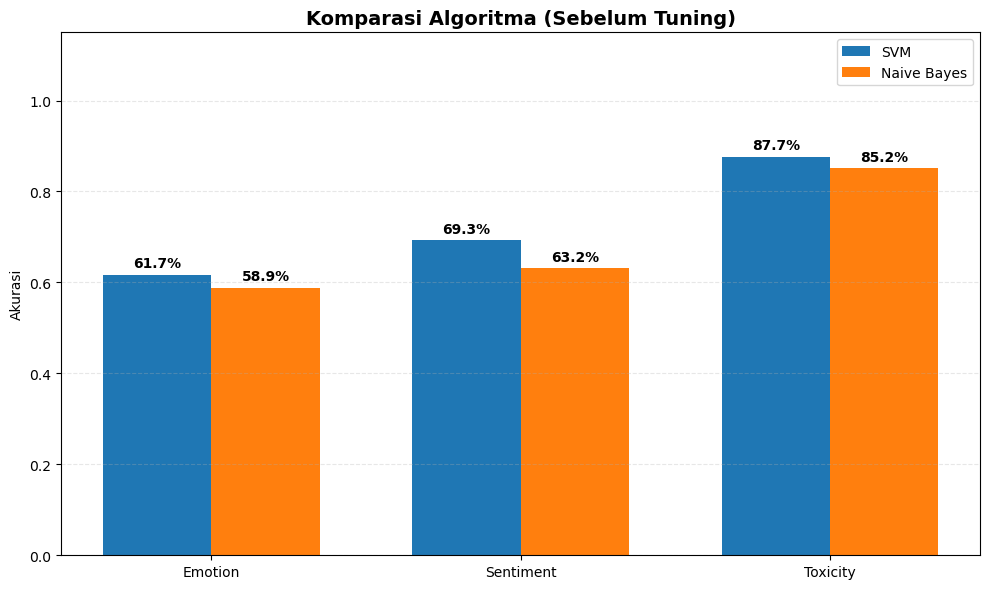

In [26]:
print("Perbandingan SVM dan Naive Bayes setelah ditrain")

topics = list(skor_akurasi.keys())
svm_scores = [skor_akurasi[t]['SVM'] for t in topics]
nb_scores = [skor_akurasi[t]['NB'] for t in topics]

x = np.arange(len(topics))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 6))

rects1 = ax.bar(x - width/2, svm_scores, width, label='SVM', color='#1f77b4') # Biru
rects2 = ax.bar(x + width/2, nb_scores, width, label='Naive Bayes', color='#ff7f0e') 

ax.set_ylabel('Akurasi')
ax.set_title('Komparasi Algoritma (Sebelum Tuning)', fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(topics)
ax.set_ylim(0, 1.15) 
ax.legend()
ax.grid(axis='y', linestyle='--', alpha=0.3)

def autolabel(rects):
    for rect in rects:
        height = rect.get_height()
        ax.annotate(f'{height*100:.1f}%',
                    xy=(rect.get_x() + rect.get_width() / 2, height),
                    xytext=(0, 3),
                    textcoords="offset points",
                    ha='center', va='bottom', fontweight='bold')

autolabel(rects1)
autolabel(rects2)

plt.tight_layout()
plt.show()

### Diagram perbandingan Model SVM sebelum dan sesudah tuning
---

Model SVM Setelah dituning


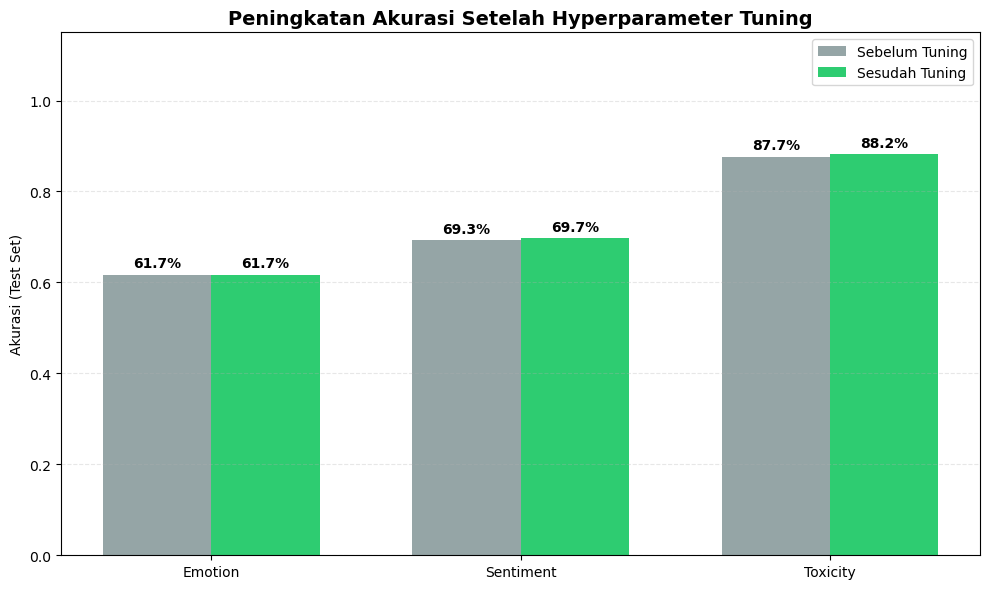

In [27]:
print("Model SVM Setelah dituning")

acc_emo_new = accuracy_score(y_test_emo, models_svm['Emotion'].predict(X_test_emo_tfidf))
acc_sen_new = accuracy_score(y_test_sen, models_svm['Sentiment'].predict(X_test_sen_tfidf))
acc_tox_new = accuracy_score(y_test_tox, models_svm['Toxicity'].predict(X_test_tox_tfidf))

topics = ['Emotion', 'Sentiment', 'Toxicity']
scores_old = [skor_akurasi['Emotion']['SVM'], skor_akurasi['Sentiment']['SVM'], skor_akurasi['Toxicity']['SVM']]
scores_new = [acc_emo_new, acc_sen_new, acc_tox_new]

x = np.arange(len(topics))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 6))
rects1 = ax.bar(x - width/2, scores_old, width, label='Sebelum Tuning', color='#95a5a6') 
rects2 = ax.bar(x + width/2, scores_new, width, label='Sesudah Tuning', color='#2ecc71') 

ax.set_ylabel('Akurasi (Test Set)')
ax.set_title('Peningkatan Akurasi Setelah Hyperparameter Tuning', fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(topics)
ax.set_ylim(0, 1.15)
ax.legend()
ax.grid(axis='y', linestyle='--', alpha=0.3)

def autolabel(rects):
    for rect in rects:
        height = rect.get_height()
        ax.annotate(f'{height*100:.1f}%',
                    xy=(rect.get_x() + rect.get_width() / 2, height),
                    xytext=(0, 3),
                    textcoords="offset points",
                    ha='center', va='bottom', fontweight='bold')

autolabel(rects1)
autolabel(rects2)

plt.tight_layout()
plt.show()

### Angka detail model terbaik (SVM)
---

In [28]:
print("\n[EMOTION DATASET]")
y_pred_emo = models_svm['Emotion'].predict(X_test_emo_tfidf)
print(classification_report(y_test_emo, y_pred_emo, target_names=sorted(df_emotion['label'].unique())))

print("\n[SENTIMENT DATASET]")
y_pred_sen = models_svm['Sentiment'].predict(X_test_sen_tfidf)
print(classification_report(y_test_sen, y_pred_sen, target_names=['Negatif', 'Positif', 'Netral']))

print("\n[TOXICITY DATASET]")
y_pred_tox = models_svm['Toxicity'].predict(X_test_tox_tfidf)
print(classification_report(y_test_tox, y_pred_tox, target_names=['Aman', 'Toxic']))


[EMOTION DATASET]
              precision    recall  f1-score   support

       anger       0.62      0.76      0.68       220
        fear       0.78      0.60      0.68       129
       happy       0.57      0.51      0.54       203
        love       0.77      0.70      0.73       127
     sadness       0.50      0.53      0.52       199

    accuracy                           0.62       878
   macro avg       0.65      0.62      0.63       878
weighted avg       0.63      0.62      0.62       878


[SENTIMENT DATASET]
              precision    recall  f1-score   support

     Negatif       0.72      0.87      0.78      1117
     Positif       0.67      0.49      0.57       505
      Netral       0.66      0.55      0.60       594

    accuracy                           0.70      2216
   macro avg       0.68      0.64      0.65      2216
weighted avg       0.69      0.70      0.69      2216


[TOXICITY DATASET]
              precision    recall  f1-score   support

        Aman   

### Confussion Matrix
---

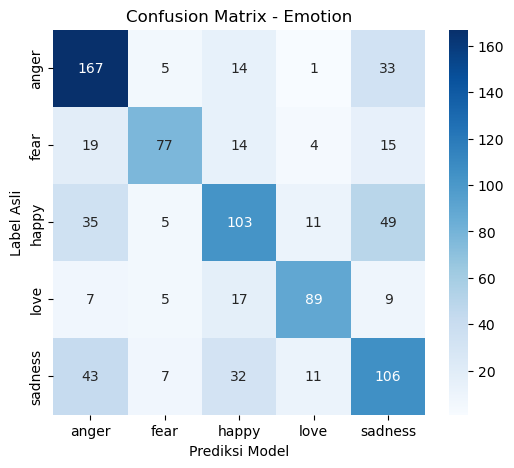

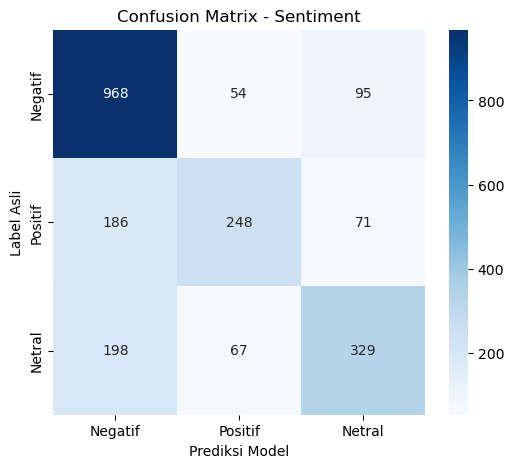

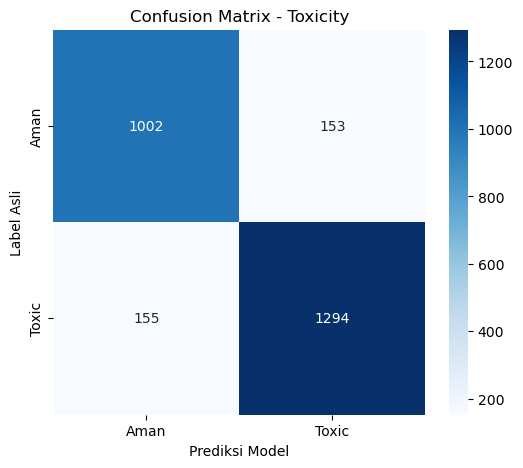

In [29]:
def gambar_matrix(topic, y_test, X_test, labels):
    if topic not in models_svm:
        print(f"Model {topic} belum ada. Pastikan sudah training dulu.")
        return

    y_pred = models_svm[topic].predict(X_test)
    cm = confusion_matrix(y_test, y_pred)

    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=labels, yticklabels=labels)
    plt.title(f'Confusion Matrix - {topic}')
    plt.xlabel('Prediksi Model')
    plt.ylabel('Label Asli')
    plt.show()

if 'labels_emo' not in globals():
    labels_emo = sorted(df_emotion['label'].unique())

gambar_matrix('Emotion', y_test_emo, X_test_emo_tfidf, labels_emo)
gambar_matrix('Sentiment', y_test_sen, X_test_sen_tfidf, ['Negatif', 'Positif', 'Netral'])
gambar_matrix('Toxicity', y_test_tox, X_test_tox_tfidf, ['Aman', 'Toxic'])

# 6. Model Validation

In [30]:
def prediksi_final(kalimat_input):
    print(f"Input: '{kalimat_input}'")

    kalimat_clean = bersihkan_teks(kalimat_input)

    input_emo = vect_emo.transform([kalimat_clean])
    pred_emo = models_svm['Emotion'].predict(input_emo)[0]

    input_sen = vect_sen.transform([kalimat_clean])
    pred_sen_val = models_svm['Sentiment'].predict(input_sen)[0]
    map_sen = {0: "Negatif", 1: "Positif", 2: "Netral"}
    label_sen = map_sen.get(pred_sen_val, "Unknown")

    input_tox = vect_tox.transform([kalimat_clean])
    pred_tox_val = models_svm['Toxicity'].predict(input_tox)[0]
    label_tox = "Toxic" if pred_tox_val == 1 else "Aman"
    
    print(f"Hasil Prediksi Machine Learning")
    print(f"   • Emosi      : {pred_emo.upper()}")
    print(f"   • Sentimen   : {label_sen}")
    print(f"   • Toksisitas : {label_tox}")
    print("-" * 40)

prediksi_final("Jansen orang baik")
prediksi_final("Seneng banget akhirnya bisa lulus skripsi tahun ini, makasih tuhan.")
prediksi_final("Hujan terus dari pagi, jadi batal main bola deh.")

Input: 'Jansen orang baik'
Hasil Prediksi Machine Learning
   • Emosi      : ANGER
   • Sentimen   : Positif
   • Toksisitas : Aman
----------------------------------------
Input: 'Seneng banget akhirnya bisa lulus skripsi tahun ini, makasih tuhan.'
Hasil Prediksi Machine Learning
   • Emosi      : HAPPY
   • Sentimen   : Positif
   • Toksisitas : Aman
----------------------------------------
Input: 'Hujan terus dari pagi, jadi batal main bola deh.'
Hasil Prediksi Machine Learning
   • Emosi      : HAPPY
   • Sentimen   : Negatif
   • Toksisitas : Aman
----------------------------------------
